## Chuẩn bị dữ liệu
12 câu thuộc 3 chủ đề:
- AI/ML (câu 0–3)
- Thể thao (câu 4–7)
- Ẩm thực: (câu 8–11)

In [1]:
data = [
    "machine learning is a powerful tool for data analysis",
    "deep learning uses neural networks with many layers",
    "neural network learns patterns from training data",
    "machine learning model predicts outcomes from data",
    "football player scored a goal in the game",
    "basketball game was exciting and the team won",
    "the player trained hard every day to improve skills",
    "football team played a great game this season",
    "cooking delicious food is an art and a skill",
    "the food was very tasty and delicious to eat",
    "eat healthy food every day to stay strong",
    "cooking a good meal requires fresh ingredients",
]

nhan = ['AI']*4 + ['Sport']*4 + ['Food']*4

print(f"Số câu {len(data)}")
for i, s in enumerate(data):
    print(f"{i}: {s}")

Số câu 12
0: machine learning is a powerful tool for data analysis
1: deep learning uses neural networks with many layers
2: neural network learns patterns from training data
3: machine learning model predicts outcomes from data
4: football player scored a goal in the game
5: basketball game was exciting and the team won
6: the player trained hard every day to improve skills
7: football team played a great game this season
8: cooking delicious food is an art and a skill
9: the food was very tasty and delicious to eat
10: eat healthy food every day to stay strong
11: cooking a good meal requires fresh ingredients


## Bài 1: 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Xây dựng vocab

In [3]:
vocab = sorted({w for s in data for w in s.lower().split()})
print(f"Kích thước vocab: {len(vocab)} từ")
print(vocab)

Kích thước vocab: 65 từ
['a', 'an', 'analysis', 'and', 'art', 'basketball', 'cooking', 'data', 'day', 'deep', 'delicious', 'eat', 'every', 'exciting', 'food', 'football', 'for', 'fresh', 'from', 'game', 'goal', 'good', 'great', 'hard', 'healthy', 'improve', 'in', 'ingredients', 'is', 'layers', 'learning', 'learns', 'machine', 'many', 'meal', 'model', 'network', 'networks', 'neural', 'outcomes', 'patterns', 'played', 'player', 'powerful', 'predicts', 'requires', 'scored', 'season', 'skill', 'skills', 'stay', 'strong', 'tasty', 'team', 'the', 'this', 'to', 'tool', 'trained', 'training', 'uses', 'very', 'was', 'with', 'won']


### 1.Biểu diễn dữ liệu thành ma trận & Độ tương đồng

In [4]:
def to_vector(sentence):
    v = np.zeros(len(vocab))
    for w in sentence.lower().split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in data])
print(X.shape)
print(f'Shape của X: {X.shape}')
print(f'{X.shape[0]} hàng = {X.shape[0]} câu')
print(f'{X.shape[1]} cột = {X.shape[1]} từ trong vocab')
print()
print('Vector của câu 0 (5 từ đầu):', X[0, :5])
print('Các từ tương ứng (5 từ đầu):', vocab[:5])

(12, 65)
Shape của X: (12, 65)
12 hàng = 12 câu
65 cột = 65 từ trong vocab

Vector của câu 0 (5 từ đầu): [1. 0. 1. 0. 0.]
Các từ tương ứng (5 từ đầu): ['a', 'an', 'analysis', 'and', 'art']


Mỗi hàng là 1 câu
Mỗi cột là 1 từ vocab, cho biết từ đó xuất hiện bao nhiêu lần trong mỗi câu

### 2. Phép toán cơ bản

In [5]:
mean_vec = X.mean(axis=0) #tính trung bình theo cột

print('Shape X:', X.shape)         
print('Shape mean_vec:     ', mean_vec.shape)   

Shape X: (12, 65)
Shape mean_vec:      (65,)


In [6]:
Xc = X - mean_vec    # Xc = X centered

print('Shape X trước khi trừ:', X.shape)
print('Shape Xc sau khi trừ:', Xc.shape)
print()

# Kiểm tra: sau khi center, mean của Xc phải ≈ 0
print('Mean của X  (cột 0):', X[:, 0].mean().round(4))
print('Mean của Xc (cột 0):', Xc[:, 0].mean().round(4),
      ' ← gần 0 sau khi center')

Shape X trước khi trừ: (12, 65)
Shape Xc sau khi trừ: (12, 65)

Mean của X  (cột 0): 0.4167
Mean của Xc (cột 0): -0.0  ← gần 0 sau khi center


Minh họa về broadcasting:
Khi X - mean_vec hoạt động vì Numpy tự động align từ phải sang trái theo từng chiều. (12, 65) - (65,) Vì 2 chiều khớp
Nếu không khớp phải reshape ví dụ:
(10, 38) - (10,) không hoạt động reshape(10,1) broadcast theo cột.

### 3. Cosine Similarity

In [7]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)   
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)  
    return Xn @ Yn.T

sim_matrix = cosine_similarity(X)

print('Shape ma trận tương đồng:', sim_matrix.shape)   # (12, 12)
print('câu 0 với chính nó:', sim_matrix[0, 0].round(4))
print('câu AI với câu AI:', sim_matrix[0, 2].round(4))
print('câu AI với câu Sport:', sim_matrix[0, 5].round(4))

Shape ma trận tương đồng: (12, 12)
câu 0 với chính nó: 1.0
câu AI với câu AI: 0.126
câu AI với câu Sport: 0.0


### 4. Hàm search

In [8]:
def search(query, top_k=3):
    q_vec = to_vector(query).reshape(1, -1)

    if q_vec.sum() == 0:
        print('Không có từ nào trong query khớp với vocab')
        return []
    
    scores = cosine_similarity(q_vec, X).flatten()

    top = np.argsort(scores)[::-1][:top_k]

    return [(int(i), round(float(scores[i]), 4), data[i]) for i in top]

print('QUERY 1: "deep learning neural network"  (liên quan AI)')
for idx, score, sentence in search('deep learning neural network', top_k=3):
    print(f'[{idx}] score={score}|{sentence}')

print()
print('QUERY 2: "football player game"  (liên quan Sport)')
for idx, score, sentence in search('football player game', top_k=3):
    print(f'[{idx}] score={score}|{sentence}')

print()
print('QUERY 3: "delicious food cooking"  (liên quan Food)')
for idx, score, sentence in search('delicious food cooking', top_k=3):
    print(f'[{idx}] score={score}|{sentence}')

QUERY 1: "deep learning neural network"  (liên quan AI)
[1] score=0.5303|deep learning uses neural networks with many layers
[2] score=0.378|neural network learns patterns from training data
[3] score=0.189|machine learning model predicts outcomes from data

QUERY 2: "football player game"  (liên quan Sport)
[4] score=0.6124|football player scored a goal in the game
[7] score=0.4082|football team played a great game this season
[5] score=0.2041|basketball game was exciting and the team won

QUERY 3: "delicious food cooking"  (liên quan Food)
[8] score=0.5774|cooking delicious food is an art and a skill
[9] score=0.3849|the food was very tasty and delicious to eat
[11] score=0.2182|cooking a good meal requires fresh ingredients


In [9]:
# Nhận xét cặp giống/khác nhất
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, -1)         # loại cặp (i, i)

i_max, j_max = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)
i_min, j_min = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape)

print(f'Giống nhất: câu {i_max} & {j_max} — sim={sim_matrix[i_max,j_max]:.4f}')
print(f'  "{data[i_max]}"')
print(f'  "{data[j_max]}"')
print()
print(f'Khác nhất:  câu {i_min} & {j_min} — sim={sim_matrix[i_min,j_min]:.4f}')
print(f'  "{data[i_min]}"')
print(f'  "{data[j_min]}"')

Giống nhất: câu 0 & 3 — sim=0.3780
  "machine learning is a powerful tool for data analysis"
  "machine learning model predicts outcomes from data"

Khác nhất:  câu 0 & 5 — sim=0.0000
  "machine learning is a powerful tool for data analysis"
  "basketball game was exciting and the team won"


### Nhận xét

**Cặp giống nhau nhất** là câu 0 và câu 3 (cùng nhóm AI),
đều chứa cụm từ "machine learning" và "data" → cosine similarity cao nhất (~0.38).
Kết quả khớp trực giác vì hai câu nói về cùng một chủ đề với từ ngữ
tương tự nhau.

**Cặp khác biệt nhất** là câu 0 (AI) và câu 5 (Sport), không chia sẻ
bất kỳ từ nào trong vocab → cosine similarity = 0.0 (hai vector vuông góc).
Hoàn toàn hợp lý vì "machine learning / data" và
"basketball game / exciting / team" thuộc hai miền ngôn ngữ không liên quan.

**Similarity nội nhóm luôn cao hơn ngoại nhóm** với cả ba chủ đề.
Điều này chứng tỏ bag-of-words đã nắm bắt được sự tương đồng chủ đề
chỉ dựa trên tần suất từ, dù chưa hiểu ngữ nghĩa sâu.

**Hàm search trả về đúng chủ đề** ở cả ba query:
query AI → top 3 đều là câu AI, query Sport → top 3 đều là câu Sport,
query Food → top 3 đều là câu Food. Kết quả khớp trực giác, xác nhận
cosine similarity là nền tảng hợp lý cho bài toán tìm kiếm văn bản.

## Bài 2: Biến đổi tuyến tính & SVD (Lựa chọn B — Text)

### 2.2: Giảm chiều bằng SVD

In [10]:
Xc = X - X.mean(axis=0)   

print('X  shape:', X.shape)
print('Xc shape:', Xc.shape)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

print('Shapes sau SVD:')
print(f'U: {U.shape}')
print(f'S: {S.shape}')
print(f'Vt: {Vt.shape}')

coords = U[:, :2] * S[:2] 

print('Shape tọa độ 2D:', coords.shape)   
print()
print('Tọa độ 2D của từng câu:')
for i, (x, y) in enumerate(coords):
    print(f'Câu {i:2d}({x:+.4f}, {y:+.4f})')

X  shape: (12, 65)
Xc shape: (12, 65)
Shapes sau SVD:
U: (12, 12)
S: (12,)
Vt: (12, 65)
Shape tọa độ 2D: (12, 2)

Tọa độ 2D của từng câu:
Câu  0(-1.6106, +0.0900)
Câu  1(-1.0069, +0.7908)
Câu  2(-1.0590, +0.7969)
Câu  3(-1.4196, +0.8245)
Câu  4(+0.3182, -1.3692)
Câu  5(+0.8420, -0.9509)
Câu  6(+1.3474, +0.9580)
Câu  7(-0.1690, -1.7356)
Câu  8(+0.2613, -0.5576)
Câu  9(+1.6575, +0.4690)
Câu 10(+1.2459, +1.3639)
Câu 11(-0.4073, -0.6797)


### 2.3: Trực quan hóa:

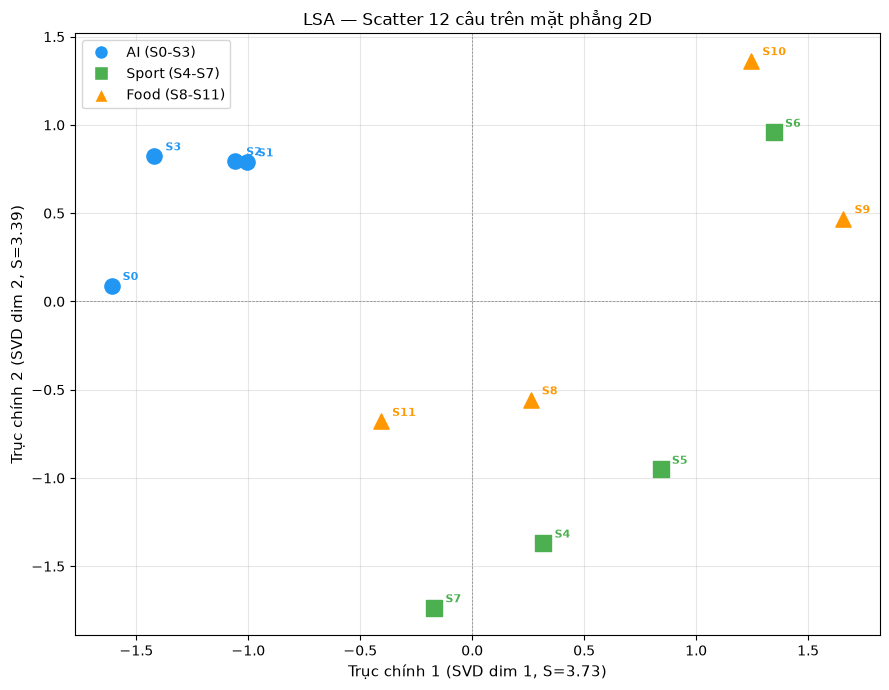

Đã lưu bai2_scatter.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

mau_nhom  = {'AI': '#2196F3', 'Sport': '#4CAF50', 'Food': '#FF9800'}
marker_nhom = {'AI': 'o', 'Sport': 's', 'Food': '^'}

# Vẽ từng điểm
for i, (x, y) in enumerate(coords):
    nhom = nhan[i]
    ax.scatter(x, y,
               color=mau_nhom[nhom],
               marker=marker_nhom[nhom],
               s=120, zorder=3)
    ax.annotate(
        f'S{i}',
        (x, y),
        textcoords='offset points', xytext=(8, 4),
        fontsize=8, color=mau_nhom[nhom], fontweight='bold'
    )

# Legend thủ công
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2196F3',
           markersize=10, label='AI (S0-S3)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#4CAF50',
           markersize=10, label='Sport (S4-S7)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#FF9800',
           markersize=10, label='Food (S8-S11)'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

# Đường kẻ trục
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'Trục chính 1 (SVD dim 1, S={S[0]:.2f})', fontsize=11)
ax.set_ylabel(f'Trục chính 2 (SVD dim 2, S={S[1]:.2f})', fontsize=11)
ax.set_title('LSA — Scatter 12 câu trên mặt phẳng 2D')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bai2_scatter.png', dpi=120)
plt.show()
print('Đã lưu bai2_scatter.png')

### 2.4: Nhận xét:
**Nhận xét:**

1. **Các câu cùng chủ đề có nằm gần nhau không?**
   - Nhìn vào scatter plot 2D: các câu AI (S0–S3), Sport (S4–S7) và Food (S8–S11) **tạo thành 3 cụm riêng biệt**.

2. **Liên hệ với PCA và "trục chính":**
   - SVD trên dữ liệu đã center tương đương với PCA. Mỗi **singular vector** (hàng của Vt) là một trục chính (eigenvector của ma trận hiệp phương sai).
   - **Trục chính 1:** hướng biến thiên nhiều nhất trong dữ liệu, phân tách nhóm nhiều nhất.
   - **Trục chính 2:** hướng biến thiên lớn thứ hai, vuông góc với trục 1.

3. **Ý nghĩa của singular values (Scree Plot):**
   - S[0] >> S[1] >> S[2]... → chiều giảm nhanh, tức là **phần lớn thông tin nằm ở vài chiều đầu**.
